In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Import

In [3]:
orders = pd.read_csv('Final_orders.csv')

In [4]:
orders.head()

,Unnamed: 0,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,order_year,order_month,order_day,week_day,net_revenue,crisis_phase
0,0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,2025,1,1,Wednesday,466.74,Pre-crisis
1,1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,2025,1,1,Wednesday,283.13,Pre-crisis
2,2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,2025,1,1,Wednesday,454.61,Pre-crisis
3,3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,2025,1,1,Wednesday,293.56,Pre-crisis
4,4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,2025,1,1,Wednesday,305.90,Pre-crisis


In [5]:
orders = orders.iloc[:,1:]

In [6]:
orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,order_year,order_month,order_day,week_day,net_revenue,crisis_phase
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,2025,1,1,Wednesday,466.74,Pre-crisis
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,2025,1,1,Wednesday,283.13,Pre-crisis
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,2025,1,1,Wednesday,454.61,Pre-crisis
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,2025,1,1,Wednesday,293.56,Pre-crisis
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,2025,1,1,Wednesday,305.90,Pre-crisis


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             149166 non-null  object 
 1   customer_id          149166 non-null  object 
 2   restaurant_id        149166 non-null  object 
 3   delivery_partner_id  149166 non-null  object 
 4   order_timestamp      149166 non-null  object 
 5   subtotal_amount      149166 non-null  float64
 6   discount_amount      149166 non-null  float64
 7   delivery_fee         149166 non-null  float64
 8   total_amount         149166 non-null  float64
 9   is_cod               149166 non-null  object 
 10  is_cancelled         149166 non-null  object 
 11  order_year           149166 non-null  int64  
 12  order_month          149166 non-null  int64  
 13  order_day            149166 non-null  int64  
 14  week_day             149166 non-null  object 
 15  net_revenue      

In [8]:
orders['crisis_phase'].value_counts()

crisis_phase
Pre-crisis    113111
Recovery       26355
Crisis          9700
Name: count, dtype: int64

In [9]:
customer = pd.read_csv('dim_customer.csv')

In [24]:
customer.head()

,customer_id,signup_date,city,acquisition_channel
0,CUST000007,21-03-2025,Pune,Organic
1,CUST000008,07-02-2025,Kolkata,Referral
2,CUST000009,25-02-2025,Delhi,Paid
3,CUST000010,28-01-2025,Hyderabad,Paid
4,CUST000011,18-01-2025,Kolkata,Organic


#### Outlier Analysis

In [10]:
numeric_cols = ['subtotal_amount','discount_amount','delivery_fee','total_amount','net_revenue']

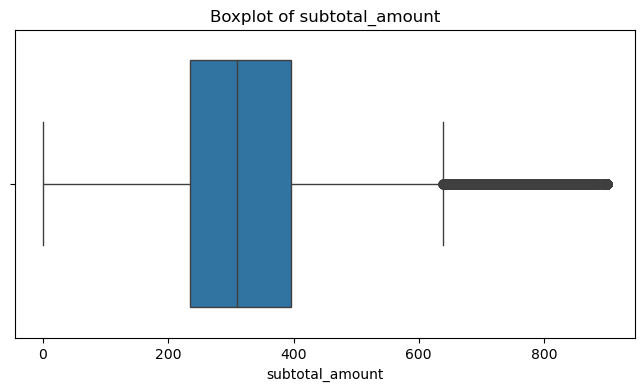

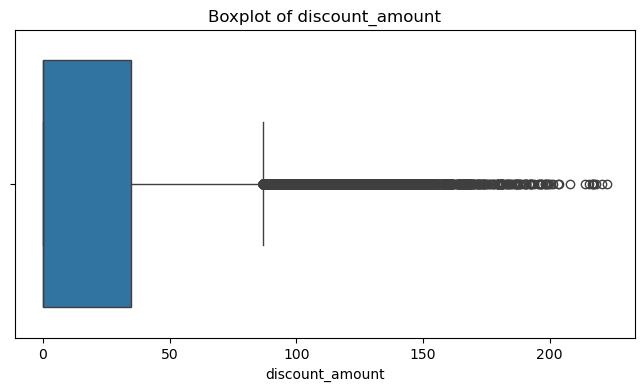

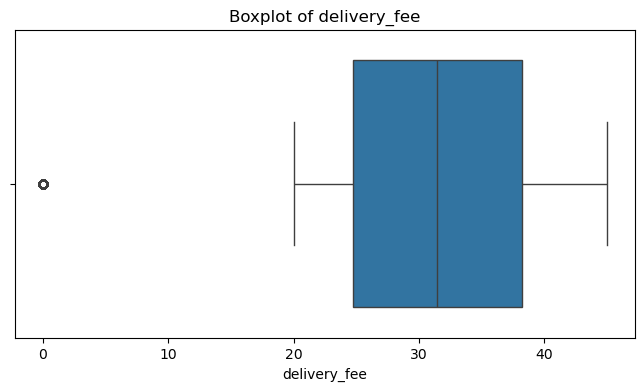

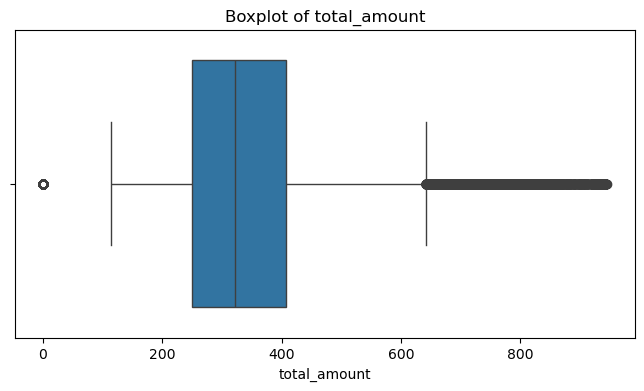

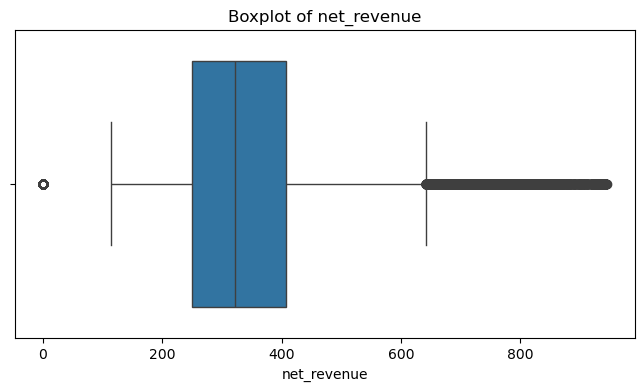

In [11]:
for col in numeric_cols:
    
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x=orders[col]
    )
    plt.title(f'Boxplot of {col}')
    plt.show()

In [12]:
orders[orders['total_amount'] == 0]

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,order_year,order_month,order_day,week_day,net_revenue,crisis_phase
15,ORD202501011873,CUST050526,REST19508,Not Assigned,2025-01-01 12:10:00,0.0,0.0,0.0,0.0,N,Y,2025,1,1,Wednesday,0.0,Pre-crisis
24,ORD202501022002,CUST114265,REST08397,Not Assigned,2025-01-01 12:15:00,0.0,0.0,0.0,0.0,N,Y,2025,1,1,Wednesday,0.0,Pre-crisis
50,ORD202501012168,CUST119646,REST12616,Not Assigned,2025-01-01 12:29:00,0.0,0.0,0.0,0.0,N,Y,2025,1,1,Wednesday,0.0,Pre-crisis
54,ORD202501023485,CUST056936,REST03176,Not Assigned,2025-01-01 12:32:00,0.0,0.0,0.0,0.0,N,Y,2025,1,1,Wednesday,0.0,Pre-crisis
57,ORD202501000523,CUST195834,REST10055,Not Assigned,2025-01-01 12:33:00,0.0,0.0,0.0,0.0,N,Y,2025,1,1,Wednesday,0.0,Pre-crisis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149143,ORD202509002895,CUST169661,REST06731,DP02548,2025-09-30 22:16:00,0.0,0.0,0.0,0.0,Y,Y,2025,9,30,Tuesday,0.0,Recovery
149146,ORD202509005099,CUST040380,REST14432,Not Assigned,2025-09-30 22:19:00,0.0,0.0,0.0,0.0,Y,Y,2025,9,30,Tuesday,0.0,Recovery
149156,ORD202509003738,CUST147227,REST05675,Not Assigned,2025-09-30 22:38:00,0.0,0.0,0.0,0.0,Y,Y,2025,9,30,Tuesday,0.0,Recovery
149161,ORD202509003524,CUST080037,REST12269,DP13152,2025-09-30 22:51:00,0.0,0.0,0.0,0.0,N,Y,2025,9,30,Tuesday,0.0,Recovery


####  78% data is cancelled

#### Revenue Trend Analysis

In [13]:
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])

##### Monthly Revenue

In [14]:
monthly_rev = orders[orders['is_cancelled'] == 'N'
].groupby(orders['order_month'])['total_amount'].sum()

In [15]:
monthly_rev

order_month
1    7774293.34
2    7469953.31
3    7802568.99
4    7126972.24
5    7447176.37
6    2887866.91
7    2724623.29
8    2642856.29
9    2684804.82
Name: total_amount, dtype: float64

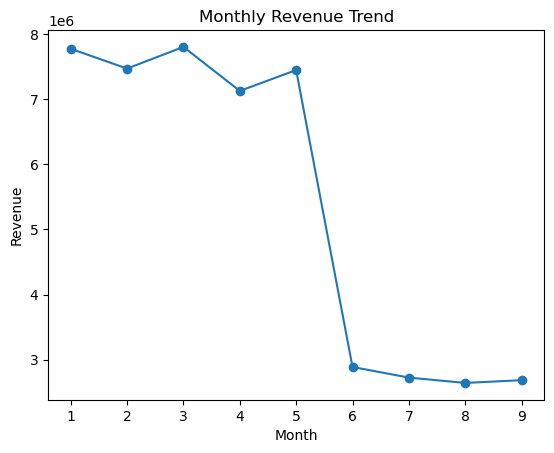

In [16]:
monthly_rev.plot(
    kind = 'line',
    marker = 'o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

#### In June, crisis has happen

In [17]:
orders_by_day = orders[orders['is_cancelled'] == 'N'
].groupby(orders['week_day'])['order_id'].count()

In [18]:
orders_by_day

week_day
Friday       20075
Monday       19391
Saturday     19826
Sunday       19528
Thursday     19935
Tuesday      19415
Wednesday    19884
Name: order_id, dtype: int64

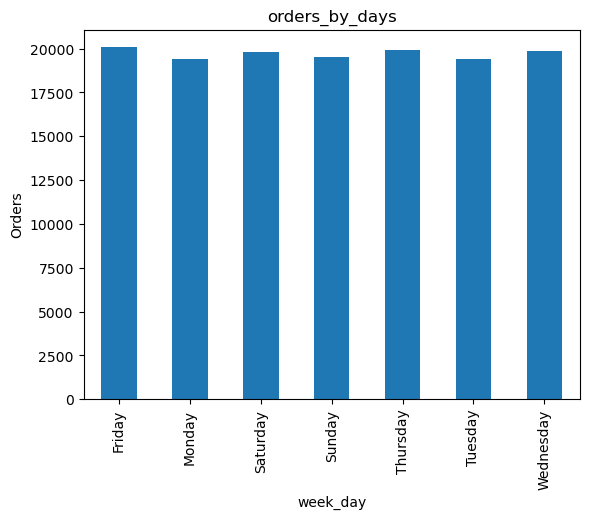

In [19]:
orders_by_day.plot(
    kind='bar'
)
plt.title('orders_by_days')
plt.ylabel('Orders')
plt.show()

#### Customer Behaviour Analysis

In [20]:
unique_cust = orders['customer_id'].nunique()

In [21]:
print(f'Total Unique Customer: {unique_cust}')

Total Unique Customer: 105180


In [22]:
top_customer = orders.groupby(['customer_id'])['net_revenue'].sum().sort_values(ascending=False).head(10)

In [23]:
top_customer

customer_id
CUST077722    2715.18
CUST146179    2526.41
CUST133600    2497.09
CUST077309    2491.28
CUST179266    2404.05
CUST125990    2403.16
CUST163628    2397.56
CUST087364    2386.77
CUST199282    2376.16
CUST165515    2349.96
Name: net_revenue, dtype: float64

In [25]:
merged_df = pd.merge(orders,
                    customer,
                    on = 'customer_id')

In [26]:
merged_df.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,order_year,order_month,order_day,week_day,net_revenue,crisis_phase,signup_date,city,acquisition_channel
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,2025,1,1,Wednesday,466.74,Pre-crisis,13-12-2024,Hyderabad,Social
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,2025,1,1,Wednesday,283.13,Pre-crisis,03-11-2024,Bengaluru,Organic
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,2025,1,1,Wednesday,454.61,Pre-crisis,28-12-2024,Kolkata,Organic
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,2025,1,1,Wednesday,293.56,Pre-crisis,08-12-2024,Bengaluru,Organic
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,2025,1,1,Wednesday,305.90,Pre-crisis,11-11-2024,Bengaluru,Social


In [29]:
channel_acq = merged_df.groupby('acquisition_channel')['order_id'].count()

In [2]:
75778+32690+20818+14827

144113

In [3]:
75778/144113

0.525823485736887

In [30]:
channel_acq

acquisition_channel
Organic     75778
Paid        32690
Referral    20818
Social      14827
Name: order_id, dtype: int64

#### 52% orders come organic. That means organic is their most powerful.

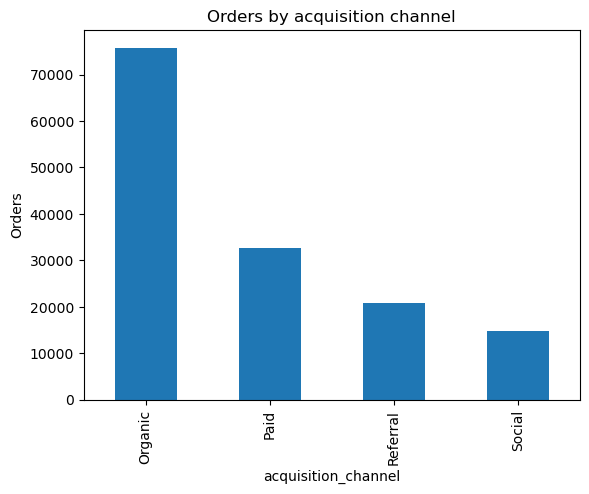

In [31]:
channel_acq.plot(
    kind = 'bar'
)

plt.title('Orders by acquisition channel')
plt.ylabel('Orders')
plt.show()

In [38]:
channel_acq_rec = merged_df[merged_df['crisis_phase'] == 'Crisis'
].groupby(merged_df['acquisition_channel'])['order_id'].count()

In [4]:
4726+2160+1326+985

9197

In [5]:
4726/9197

0.5138632162661737

In [39]:
channel_acq_rec

acquisition_channel
Organic     4726
Paid        2160
Referral    1326
Social       985
Name: order_id, dtype: int64

#### During crisis phase, organic orders are their strength. 51% orders are organic.

In [42]:
city_orders = merged_df.groupby('city')['order_id'].count().sort_values(ascending=False)

In [43]:
city_orders

city
Bengaluru    40588
Mumbai       23170
Delhi        20284
Chennai      14567
Hyderabad    14177
Pune         11479
Ahmedabad     9951
Kolkata       9897
Name: order_id, dtype: int64

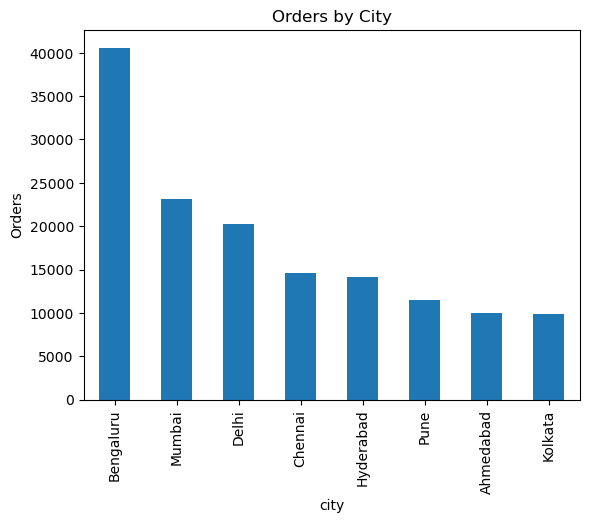

In [44]:
city_orders.plot(
    kind = 'bar'
)

plt.title('Orders by City')
plt.ylabel('Orders')
plt.show()

#### Bengaluru is highest revenue generater in cities follwed by Mumbai, Delhi & Chennai

In [45]:
aov = round(orders['net_revenue'].mean(),2)

In [46]:
aov

325.55

In [48]:
aov_phase = orders.groupby('crisis_phase').agg(
    total_revenue=('total_amount','sum'),
    total_orders=('order_id','count')
)

aov_phase['AOV'] = (
    aov_phase['total_revenue']
    /
    aov_phase['total_orders']
)

print(aov_phase)

              total_revenue  total_orders         AOV
crisis_phase                                         
Crisis           3032856.52          9700  312.665621
Pre-crisis      37390172.25        113111  330.561769
Recovery         8138086.79         26355  308.787205


#### AOV is almost 300-350 during all the crisis phase.